**Student Performance Project**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# Display settings
pd.set_option("display.max_columns", None)

**Cleaning & Preprocessing**

In [ ]:
df=pd.read_csv("/content/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
df.shape

(6607, 20)

In [ ]:
# checking null values

df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
# filling null values

df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

In [ ]:
# checking duplicates
df.duplicated().sum()
#there are no duplicates
df.drop_duplicates(inplace=True)


In [ ]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=["int64"]).columns
categorical_columns =df.select_dtypes(include=["object"]).columns

print("Numerical Columns:",numerical_columns)
print("\nCategorical Columns:",categorical_columns)



Numerical Columns: Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')

Categorical Columns: Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


**Exploratory Data Analysis**

In [ ]:
# performance category based on exam score
def performance_category(score):
    if score >= 75:
        return "High"
    elif score >= 60:
        return "Medium"
    else:
        return "Low"

df["Performance_Level"] = df["Exam_Score"].apply(performance_category)

df["Performance_Level"].value_counts()


,count
Performance_Level,
Medium,6415
High,124
Low,68


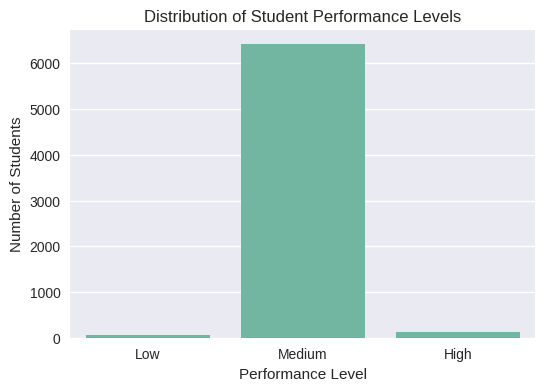

In [ ]:
#Performance Level Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Performance_Level", data=df, order=["Low", "Medium", "High"])
plt.title("Distribution of Student Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.show()



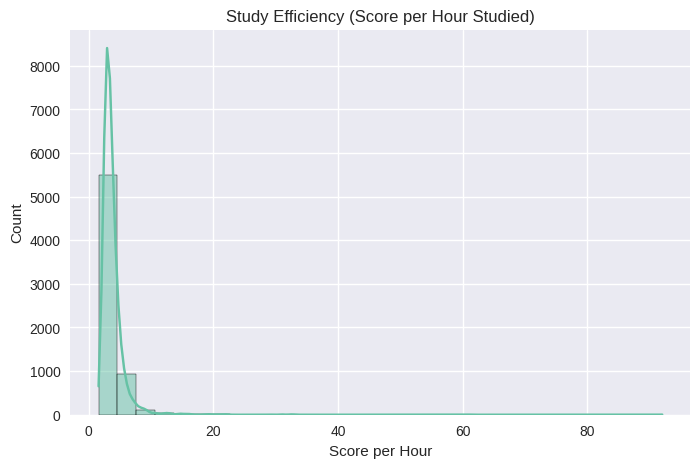

In [ ]:
#Exam Score per Hour Studied
df["Score_per_Hour"] = df["Exam_Score"] / df["Hours_Studied"]

plt.figure(figsize=(8,5))
sns.histplot(df["Score_per_Hour"], bins=30, kde=True)
plt.title("Study Efficiency (Score per Hour Studied)")
plt.xlabel("Score per Hour")
plt.show()


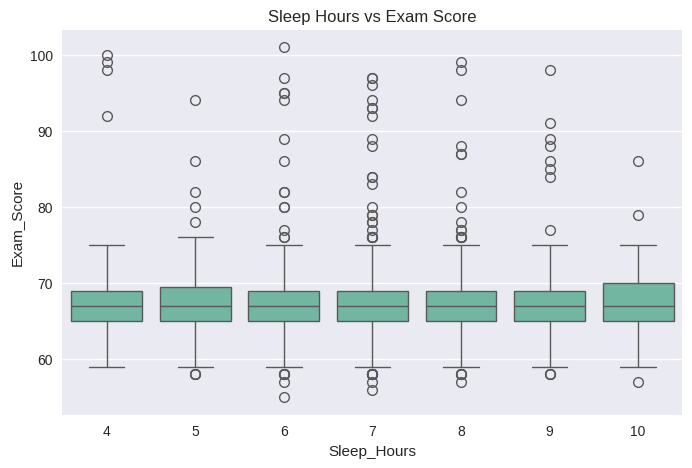

In [ ]:
#Sleep vs Performance Trade-off
plt.figure(figsize=(8,5))
sns.boxplot(x="Sleep_Hours", y="Exam_Score", data=df)
plt.title("Sleep Hours vs Exam Score")
plt.show()


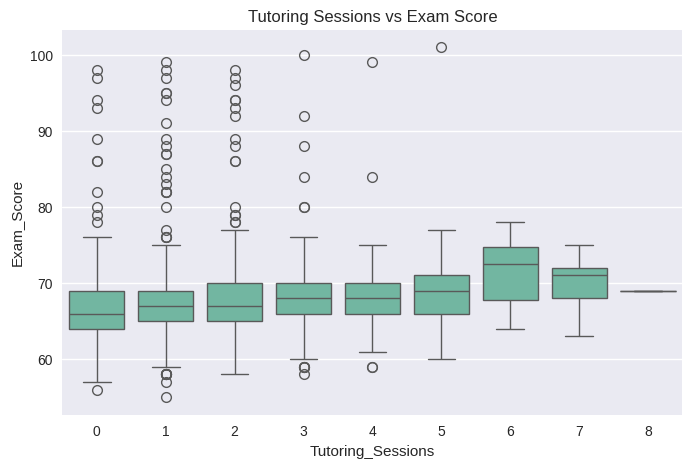

In [ ]:
#Tutoring Impact Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x="Tutoring_Sessions", y="Exam_Score", data=df)
plt.title("Tutoring Sessions vs Exam Score")
plt.show()


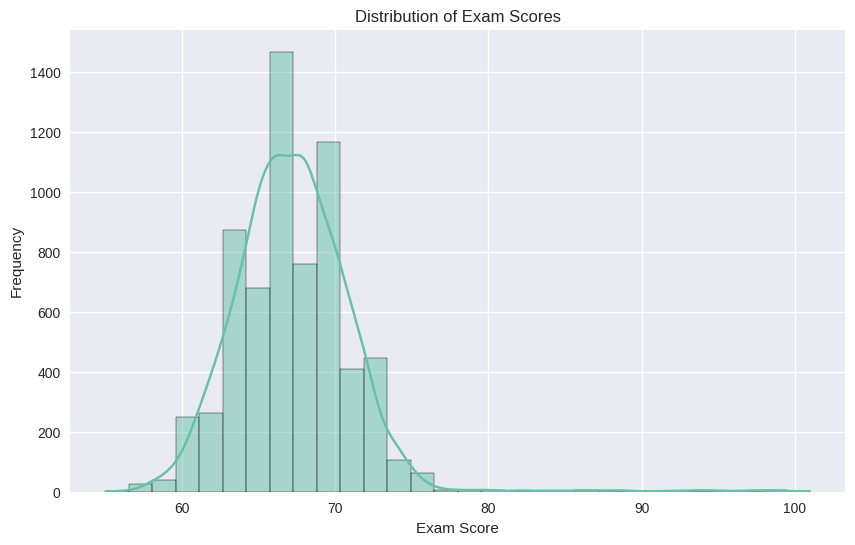

In [ ]:
#Distribution of Exam Scores

plt.figure(figsize=(10, 6))
sns.histplot(df["Exam_Score"],bins=30,kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

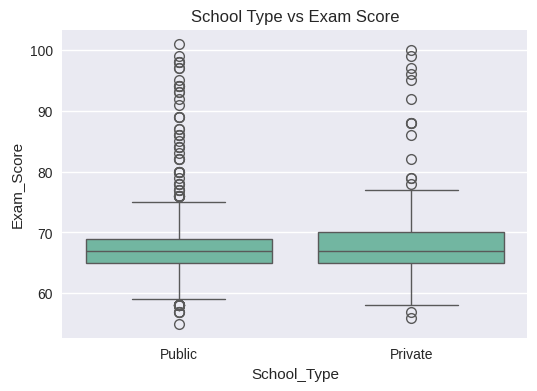

In [ ]:
#School Type Comparison
plt.figure(figsize=(6,4))
sns.boxplot(x="School_Type", y="Exam_Score", data=df)
plt.title("School Type vs Exam Score")
plt.show()



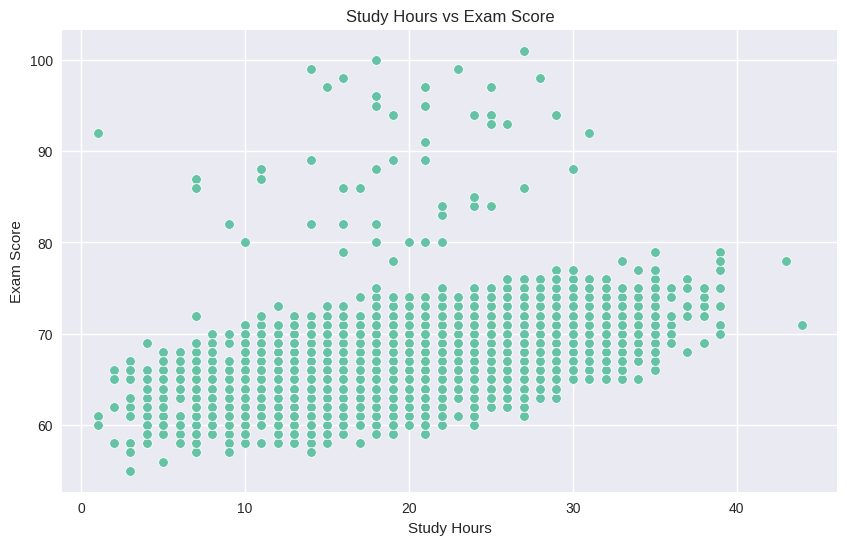

In [ ]:
#Study Hours vs Exam Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()



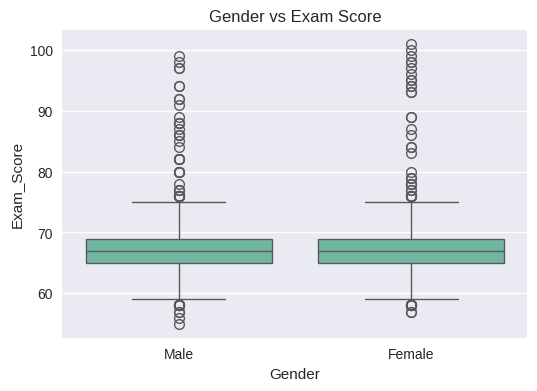

In [ ]:
#Gender-Based Performance Analysis
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Exam_Score", data=df)
plt.title("Gender vs Exam Score")
plt.show()


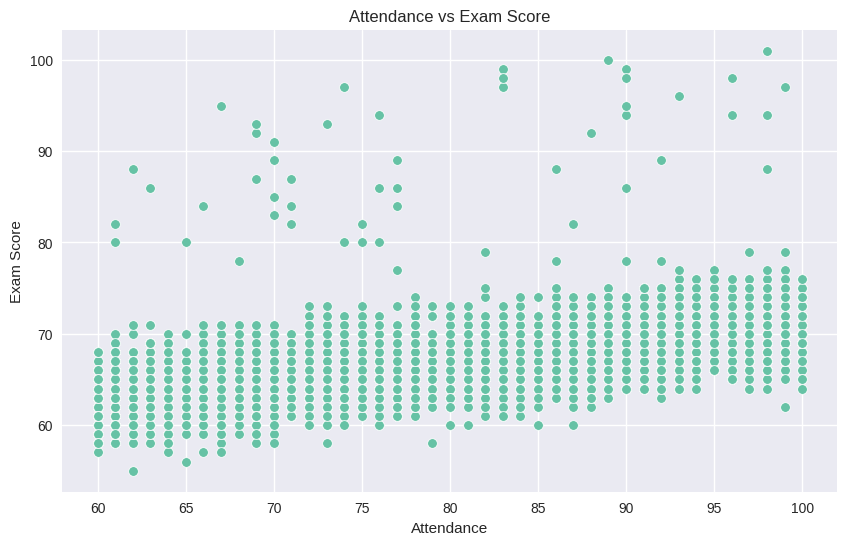

In [ ]:
#Attendence Vs Exam Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Attendance", y="Exam_Score", data=df)
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()

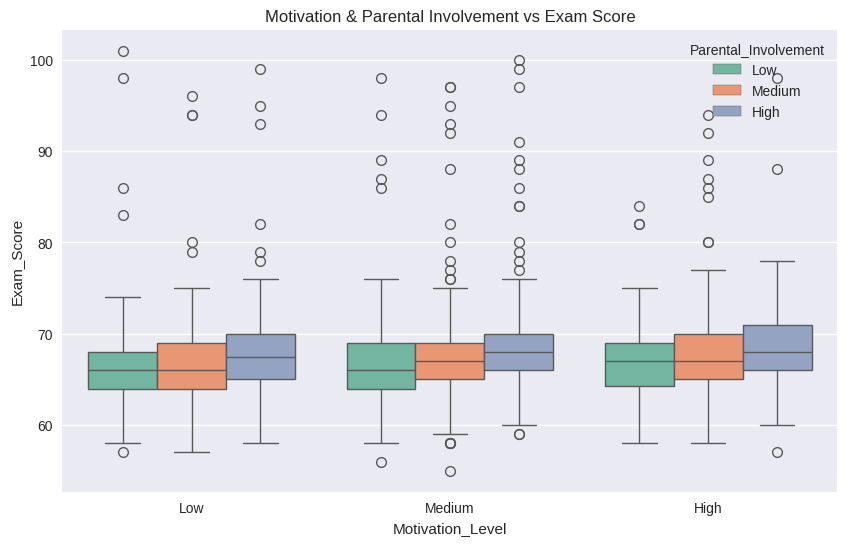

In [ ]:
#Motivation Level + Parental Involvement
plt.figure(figsize=(10,6))
sns.boxplot(
    x="Motivation_Level",
    y="Exam_Score",
    hue="Parental_Involvement",
    data=df
)
plt.title("Motivation & Parental Involvement vs Exam Score")
plt.show()



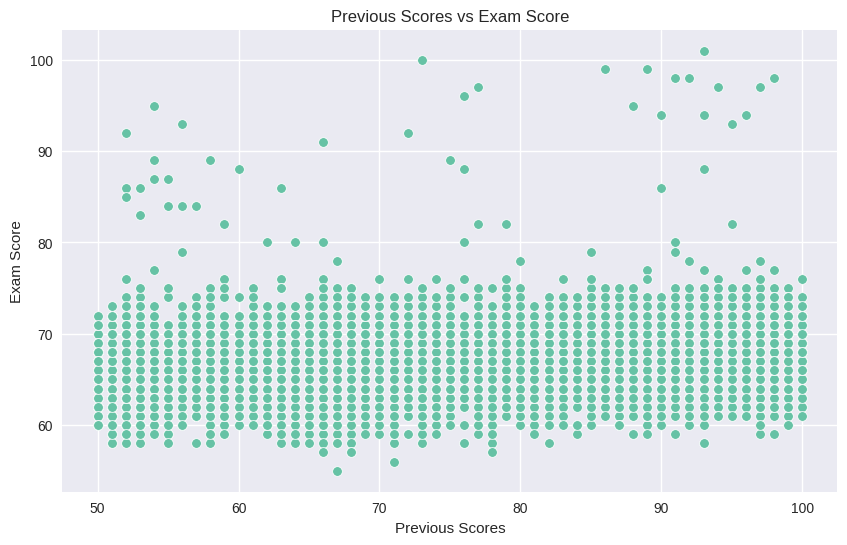

In [ ]:
#Previous Scores vs Exam Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Previous_Scores", y="Exam_Score", data=df)
plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.show()

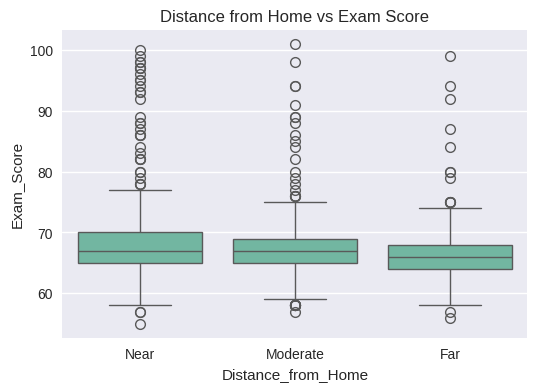

In [ ]:
#Distance from Home Analysis
plt.figure(figsize=(6,4))
sns.boxplot(x="Distance_from_Home", y="Exam_Score", data=df)
plt.title("Distance from Home vs Exam Score")
plt.show()



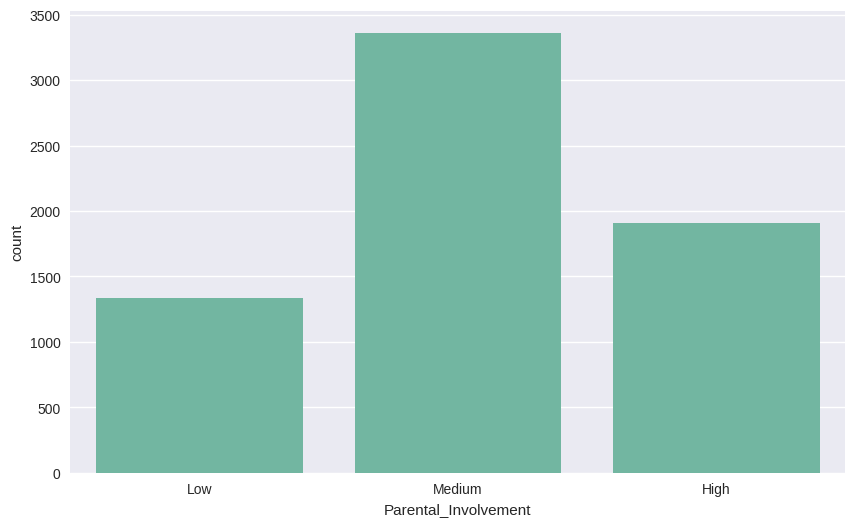

In [ ]:
#Categorical Feature Analysis >> Parental Involvement
plt.figure(figsize=(10, 6))
sns.countplot(x="Parental_Involvement", data=df)
plt.show()

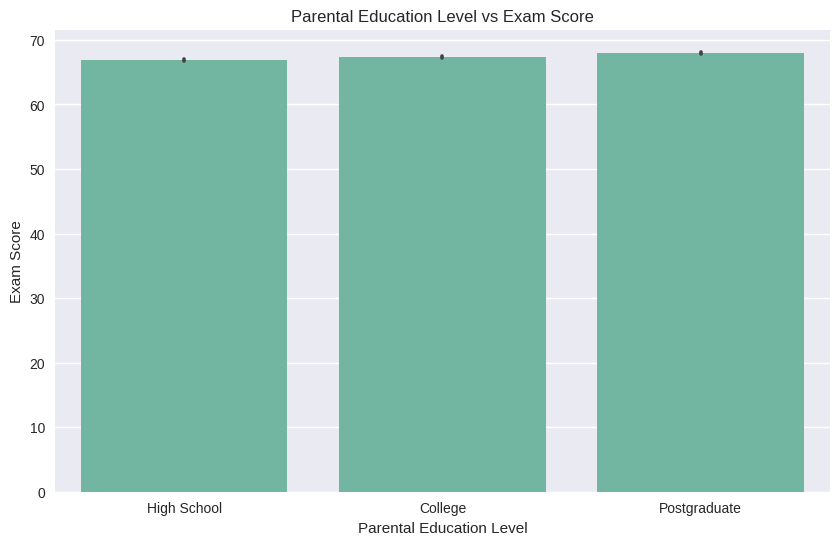

In [ ]:
#Parental Education Level vs Exam Score
plt.figure(figsize=(10, 6))
sns.barplot(x="Parental_Education_Level",y="Exam_Score" ,data=df)
plt.title("Parental Education Level vs Exam Score")
plt.xlabel("Parental Education Level")
plt.ylabel("Exam Score")
plt.show()

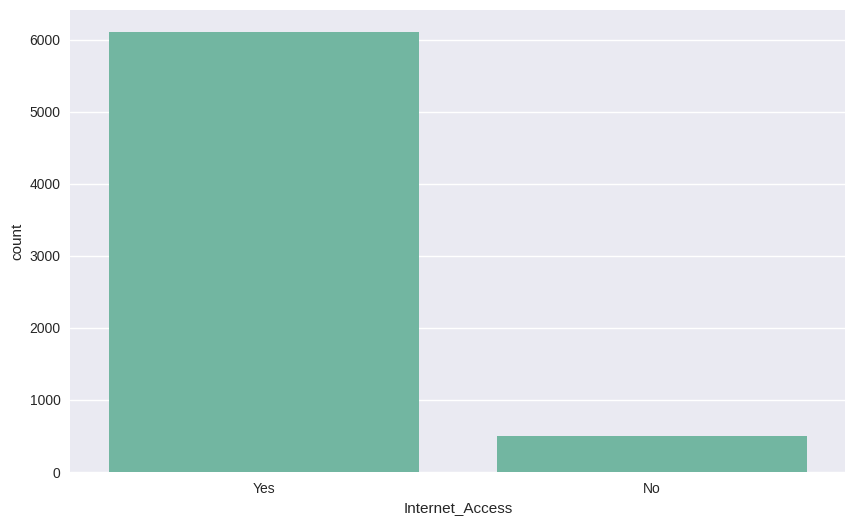

In [ ]:
# internet Access count plot
plt.figure(figsize=(10, 6))
sns.countplot(x="Internet_Access", data=df)
plt.show()

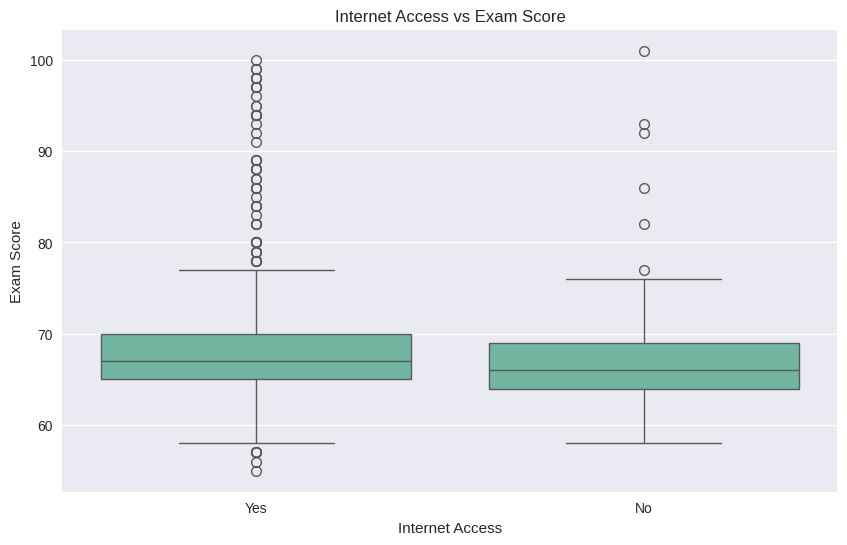

In [ ]:
# Iternet Access and Exam Score
plt.figure(figsize=(10, 6))
sns.boxplot(x="Internet_Access", y="Exam_Score", data=df)
plt.title("Internet Access vs Exam Score")
plt.xlabel("Internet Access")
plt.ylabel("Exam Score")
plt.show()

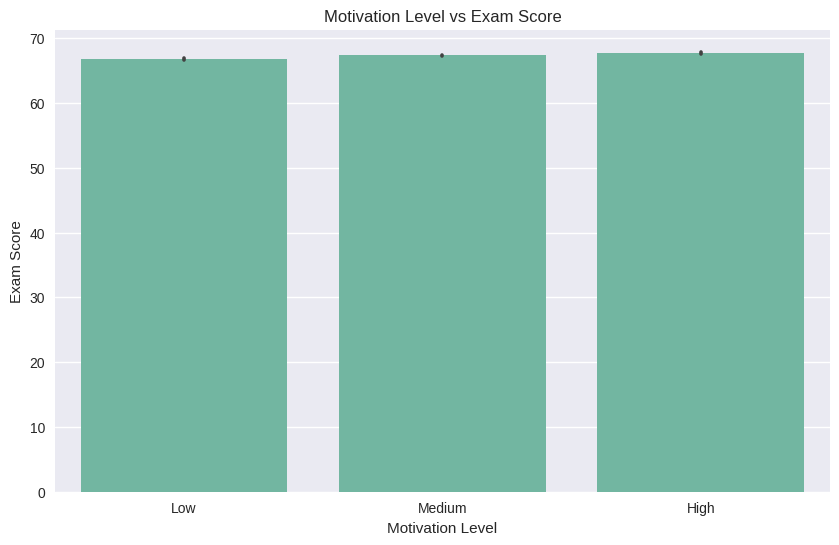

In [ ]:
#Motivation Level and Exam Score
plt.figure(figsize=(10, 6))
sns.barplot(x="Motivation_Level", y="Exam_Score", data=df)
plt.title("Motivation Level vs Exam Score")
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")
plt.show()

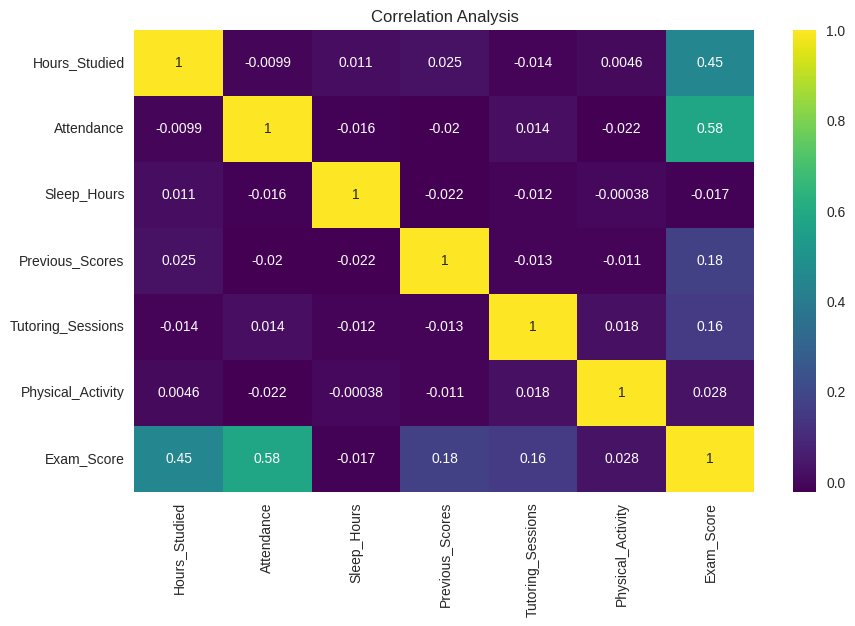

In [ ]:
#Correlation Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_columns].corr(),annot=True,cmap="viridis")
plt.title("Correlation Analysis")
plt.show()



#  Data-Driven Recommendations

**(Based on Student Performance Analysis)**

---

## 1. Promote Quality Study Over Quantity

**Evidence:**

* Study efficiency analysis showed that some students achieve high scores with fewer study hours.

**Recommendation:**

* Schools should train students on **effective study techniques** (active recall, spaced repetition) rather than encouraging excessive study hours.
* Introduce workshops on **time management and smart studying**.

---

## 2. Encourage Healthy Sleep Patterns

**Evidence:**

* Students sleeping **7–8 hours** consistently achieved better exam scores.

**Recommendation:**

* Schools and parents should promote balanced schedules that avoid late-night studying.
* Awareness programs on **sleep and academic performance** should be introduced.

---

## 3. Improve Attendance Monitoring and Engagement

**Evidence:**

* Strong positive relationship between **attendance and exam scores**.

**Recommendation:**

* Implement early-warning systems for students with declining attendance.
* Increase classroom engagement to motivate consistent attendance.

---

## 4. Balance Academics with Physical Activity

**Evidence:**

* Moderate physical activity correlated with better performance.

**Recommendation:**

* Schools should maintain regular **physical education sessions**.
* Encourage extracurricular sports to reduce stress and improve focus.

---

##  5. Increase Parental Involvement

**Evidence:**

* Higher parental involvement led to better performance across all motivation levels.

**Recommendation:**

* Schools should improve **parent-teacher communication**.
* Provide parents with guidance on how to support students academically at home.

---

##  6. Focus on Student Motivation Programs

**Evidence:**

* Motivation level showed a strong impact on exam scores.

**Recommendation:**

* Introduce mentoring, goal-setting sessions, and recognition programs.
* Provide counseling support to low-motivation students.

---

##  7. Use Tutoring Strategically

**Evidence:**

* Moderate tutoring improved performance, but excessive tutoring showed diminishing returns.

**Recommendation:**

* Offer **targeted tutoring** for struggling students instead of blanket tutoring.
* Monitor tutoring effectiveness regularly.

---

##  8. Ensure Basic Access to Learning Resources

**Evidence:**

* Internet access and learning resources provided a performance advantage.

**Recommendation:**

* Schools should ensure students have **minimum digital access**.
* Provide offline alternatives where internet access is limited.

---

##  9. Support Students Living Far from School

**Evidence:**

* Students living farther from school showed slightly lower performance.

**Recommendation:**

* Offer flexible schedules or academic support for long-commute students.
* Explore transportation or hybrid learning solutions.

---

## Final Strategic Recommendation

**Key Insight:**
Student performance is **multi-factorial**.

**Overall Recommendation:**

> Educational institutions should adopt a **holistic student development strategy** that balances academics, mental health, family support, and lifestyle factors instead of focusing on grades alone.

---



**Key Insights**


-Hours studied and previous scores have a strong positive relationship with exam
performance.

-Attendance significantly impacts exam scores — consistent attendance leads to better results.

-Students with high parental involvement perform better on average.

-Motivation level shows a clear effect on academic outcomes.

-Internet access provides a small but noticeable advantage.

-Physical activity shows a moderate positive influence, suggesting balance matters.

-Socioeconomic factors like family income and parental education affect performance but are not sole predictors.